# Phase D2-NM retrospective follow-up

This owner-review notebook reads the sealed Phase D2-NM outputs. It does not fit
or score a model. All 2023 H1–2026 H1 evidence is retrospective
hypothesis-development and robustness evidence because inspected Phase D2 results
motivated removal of M. Nothing here is a deployment claim.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

RUN = Path("D:/Stock/data/ATS/phase_d_ml/followup_runs/phase-d2-nm-followup-20260903-v1")
AUDIT = Path("D:/Stock/data/ATS/phase_d_ml/followup_reproductions/phase-d2-nm-followup-20260903-v1-independent")
STREAM = Path("D:/Stock/data/ATS/phase_d_ml/prospective_streams/phase-d2-nm-post-freeze-2026-v3")
SUPERSESSIONS = [
    Path("D:/Stock/data/ATS/phase_d_ml/prospective_streams/supersessions/phase-d2-nm-post-freeze-2026-v1.json"),
    Path("D:/Stock/data/ATS/phase_d_ml/prospective_streams/supersessions/phase-d2-nm-post-freeze-2026-v2.json"),
]
required = ["manifest.json", "per_half_year.json", "classification.json", "concentration.json", "direct_no_m_vs_full_rich.json"]
assert all((RUN / name).is_file() for name in required)
results = json.loads((RUN / "per_half_year.json").read_text())
classification = json.loads((RUN / "classification.json").read_text())
concentration = json.loads((RUN / "concentration.json").read_text())
direct = json.loads((RUN / "direct_no_m_vs_full_rich.json").read_text())
audit = json.loads((AUDIT / "audit.json").read_text())
registration = json.loads((STREAM / "registration.json").read_text())
supersessions = [json.loads(path.read_text()) for path in SUPERSESSIONS]
assert classification["classification"] == "WEAK BUT PERSISTENT"
assert audit["status"] == "PASS" and audit["classification"] == classification["classification"]
assert all(item["prediction_rows"] == 0 for item in supersessions)
assert all(item["status"] == "NON_OPERATIONAL_SUPERSEDED_EMPTY_REGISTRATION" for item in supersessions)
print("Sealed primary and independent audit loaded: PASS")

Sealed primary and independent audit loaded: PASS


## Scientific object and population

The challenger is exactly `RICH_NO_M_LIGHTGBM` (18 C+P+X predictors). The fixed
comparators are `C_LINEAR` and `C_LIGHTGBM`; `RICH_LIGHTGBM` appears only in the
direct removal-of-M diagnostic. All comparisons use identical semantic rows,
the official TOP60 denominator, the exact 20-session split-adjusted price-only
outcome, and equal session weighting.

In [2]:
names = [f"RETRO_{year}_H{half}" for year, half in [(2023,1),(2023,2),(2024,1),(2024,2),(2025,1),(2025,2),(2026,1)]]
rank_rows = []
for name in names:
    row = results["rank"][name]
    rank_rows.append({
        "half_year": name.replace("RETRO_", "").replace("_", " "),
        "sessions": row["sessions"], "rows": row["semantic_rows"],
        "no_m_ic": row["mean_ic"]["RICH_NO_M_LIGHTGBM"],
        "delta_C_LINEAR": row["paired"]["C_LINEAR"]["mean"],
        "delta_C_LIGHTGBM": row["paired"]["C_LIGHTGBM"]["mean"],
        "delta_full_rich": row["paired"]["RICH_LIGHTGBM"]["mean"],
    })
rank_table = pd.DataFrame(rank_rows)
display(rank_table.style.format({c: "{:+.4f}" for c in ["no_m_ic","delta_C_LINEAR","delta_C_LIGHTGBM","delta_full_rich"]}))
pooled = results["rank"]["RETRO_2023_2026_H1"]
print("Pooled sessions:", pooled["sessions"], "scored rows:", pooled["semantic_rows"], "outcomes:", pooled["outcome_rows"])

,half_year,sessions,rows,no_m_ic,delta_C_LINEAR,delta_C_LIGHTGBM,delta_full_rich
0,2023 H1,124,7440,+0.0704,+0.1928,+0.1045,+0.0107
1,2023 H2,126,7555,-0.0245,-0.0103,+0.0037,-0.0776
2,2024 H1,124,7436,-0.0264,-0.0063,-0.0000,-0.0256
3,2024 H2,125,7458,+0.0824,+0.0204,+0.0658,+0.0699
4,2025 H1,123,7254,-0.0112,+0.0230,+0.0083,-0.0108
5,2025 H2,126,7410,+0.1033,+0.0455,+0.0921,+0.0559
6,2026 H1,123,7349,+0.1122,-0.0586,+0.0487,+0.0410


Pooled sessions: 871 scored rows: 51902 outcomes: 51900


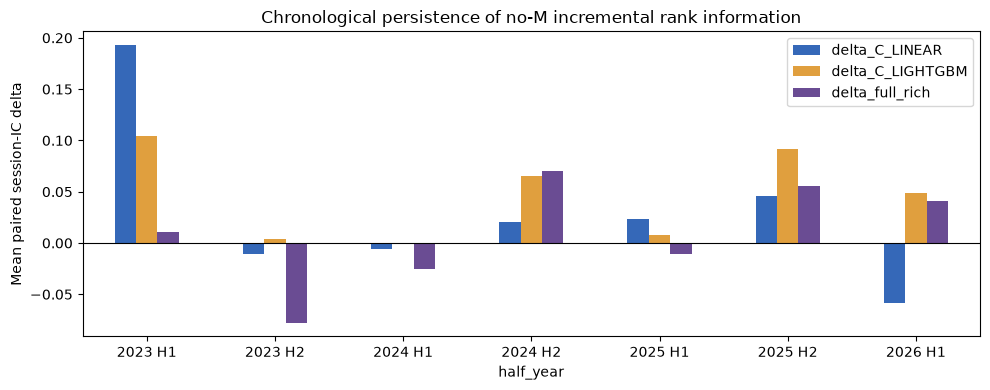

In [3]:
ax = rank_table.set_index("half_year")[["delta_C_LINEAR", "delta_C_LIGHTGBM", "delta_full_rich"]].plot(
    kind="bar", figsize=(10, 4), color=["#3568b8", "#e09f3e", "#6a4c93"]
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean paired session-IC delta")
ax.set_title("Chronological persistence of no-M incremental rank information")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

The no-M pooled IC is 0.04376. Its paired deltas are +0.02955 versus linear and
+0.04622 versus conventional LightGBM. Persistence is four of seven and six of
seven half-years. The 95% moving-block interval still crosses zero versus linear,
which is uncertainty worth monitoring but is not an extra retrospective gate.

,half_year,episodes,mean,median,vs_eligible,vs_C_LINEAR,vs_C_LIGHTGBM
0,2023 H1,14,-1.44%,-1.24%,-3.89%,+1.99%,+4.52%
1,2023 H2,19,-2.85%,-1.88%,-3.19%,-1.37%,+5.07%
2,2024 H1,85,+1.84%,+0.72%,+0.68%,+1.81%,+4.10%
3,2024 H2,86,+2.20%,+0.03%,+2.49%,+4.93%,+2.07%
4,2025 H1,58,+5.48%,+5.12%,+1.25%,+4.23%,+2.82%
5,2025 H2,40,+0.84%,-0.11%,-1.00%,-0.82%,-1.33%
6,2026 H1,62,+4.80%,+4.36%,+0.13%,-1.53%,-3.82%


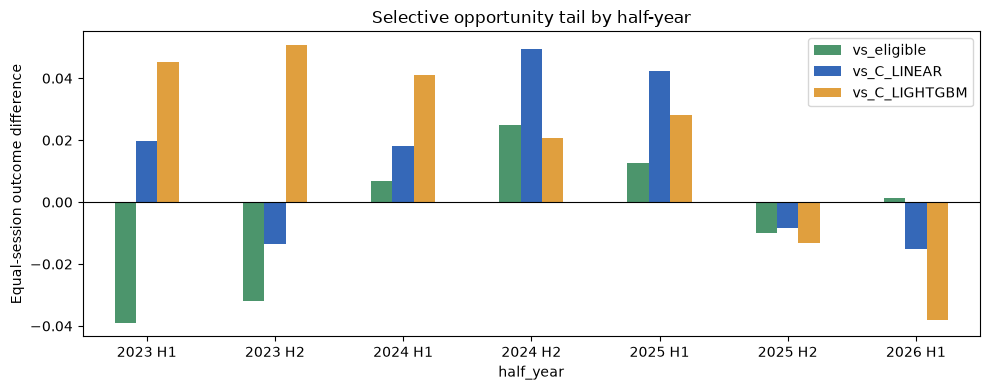

In [4]:
tail_rows = []
for name in names:
    row = results["tail"][name]
    tail_rows.append({
        "half_year": name.replace("RETRO_", "").replace("_", " "),
        "episodes": row["effective_episodes"], "mean": row["episode_mean_outcome"],
        "median": row["episode_median_outcome"], "vs_eligible": row["minus_eligible"],
        "vs_C_LINEAR": row["minus_comparator"]["C_LINEAR"],
        "vs_C_LIGHTGBM": row["minus_comparator"]["C_LIGHTGBM"],
    })
tail_table = pd.DataFrame(tail_rows)
display(tail_table.style.format({c: "{:+.2%}" for c in ["mean","median","vs_eligible","vs_C_LINEAR","vs_C_LIGHTGBM"]}))
tail_table.set_index("half_year")[["vs_eligible","vs_C_LINEAR","vs_C_LIGHTGBM"]].plot(
    kind="bar", figsize=(10,4), color=["#4c956c", "#3568b8", "#e09f3e"]
)
plt.axhline(0, color="black", linewidth=0.8); plt.ylabel("Equal-session outcome difference")
plt.title("Selective opportunity tail by half-year"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

Pooled no-M episodes average +2.53% with a +1.24% median. Equal-session
differences are +0.35% versus eligible, +1.77% versus `C_LINEAR`, and +1.60%
versus `C_LIGHTGBM`. These are opportunity diagnostics—not positions, trades, or
portfolio returns.

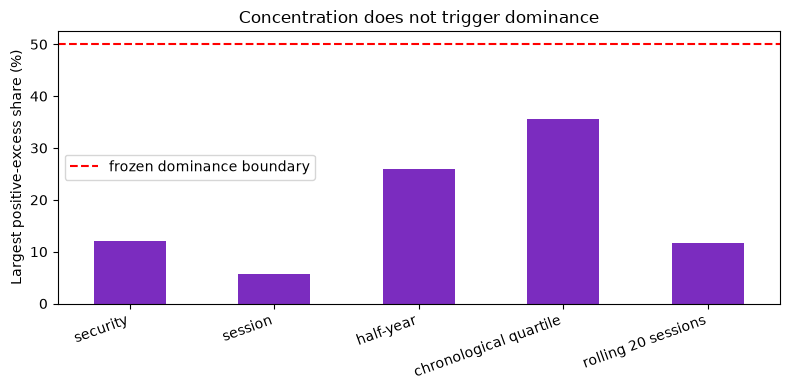

,largest_share
security,12.13%
session,5.78%
half-year,25.96%
chronological quartile,35.69%
rolling 20 sessions,11.77%


In [5]:
shares = {
    "security": concentration["security_positive_excess"]["largest_share"],
    "session": concentration["session_positive_excess"]["largest_share"],
    "half-year": concentration["half_year_positive_excess"]["largest_share"],
    "chronological quartile": concentration["largest_chronological_quartile_share"],
    "rolling 20 sessions": concentration["largest_rolling_20_session_positive_excess_share"],
}
ax = pd.Series(shares).mul(100).plot(kind="bar", figsize=(8,4), color="#7b2cbf")
ax.axhline(50, color="red", linestyle="--", label="frozen dominance boundary")
ax.set_ylabel("Largest positive-excess share (%)"); ax.set_title("Concentration does not trigger dominance")
ax.legend(); plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()
display(pd.Series(shares, name="largest_share").to_frame().style.format("{:.2%}"))

In [6]:
display(Markdown(f'''
## Mechanical classification: `{classification['classification']}`

- Pooled delta is positive against both conventional comparators.
- Positive half-years: {classification['positive_half_years']['C_LINEAR']}/7 versus `C_LINEAR`, {classification['positive_half_years']['C_LIGHTGBM']}/7 versus `C_LIGHTGBM`.
- No-M exceeds full-rich pooled IC: {classification['no_m_exceeds_full_rich']}.
- Coherent pooled opportunity tail: {classification['coherent_tail']}.
- Any dominance trigger: {any(classification['dominance'].values())}.

The strong gate needs at least five positive half-years against each comparator;
linear has only four. The independent evaluator reproduced every classification
input and returned `{audit['status']}`.
'''))


## Mechanical classification: `WEAK BUT PERSISTENT`

- Pooled delta is positive against both conventional comparators.
- Positive half-years: 4/7 versus `C_LINEAR`, 6/7 versus `C_LIGHTGBM`.
- No-M exceeds full-rich pooled IC: True.
- Coherent pooled opportunity tail: True.
- Any dominance trigger: False.

The strong gate needs at least five positive half-years against each comparator;
linear has only four. The independent evaluator reproduced every classification
input and returned `PASS`.


In [7]:
display(Markdown(f'''
## Prospective boundary

Repaired stream `{registration['stream_id']}` is registered with status
`{registration['status']}`. The preserved v1 and v2 registrations are both
`{supersessions[0]['status']}` and had zero predictions.
The accepted July–August rows remain historical canary evidence and are never
backfilled into prospective status.

A later score package is accepted only when its block exactly matches canonical
frozen-contract derivation and its estimator/preprocessing fingerprint matches
the committed training implementation. A batch qualifies only when publisher-recorded completion after atomic
finalization is no later than 08:45 Europe/Warsaw. Scorer-supplied publication
times have no authority. Fewer than 40 timely decision sessions makes the early
checkpoint `INSUFFICIENT`, not failure.
'''))


## Prospective boundary

Repaired stream `phase-d2-nm-post-freeze-2026-v3` is registered with status
`ACTIVE_EMPTY_AWAITING_ELIGIBLE_SESSION`. The preserved v1 and v2 registrations are both
`NON_OPERATIONAL_SUPERSEDED_EMPTY_REGISTRATION` and had zero predictions.
The accepted July–August rows remain historical canary evidence and are never
backfilled into prospective status.

A later score package is accepted only when its block exactly matches canonical
frozen-contract derivation and its estimator/preprocessing fingerprint matches
the committed training implementation. A batch qualifies only when publisher-recorded completion after atomic
finalization is no later than 08:45 Europe/Warsaw. Scorer-supplied publication
times have no authority. Fewer than 40 timely decision sessions makes the early
checkpoint `INSUFFICIENT`, not failure.


## Owner boundary

This result justifies keeping the fixed prediction stream running and discussing,
not implementing, one later specifically motivated feature hypothesis. Phase D3,
a portfolio/backtest, a new feature block, optimization, live trading, and any
deployment claim remain unauthorized.